# **Estadística computacional - Grupo B**

**Integrantes:**

- Cristóbal Flores Campusano 

  Rol: 202473111-4
- Joaquín Solís Quintanilla 

  Rol: 202404077-4

- Josefa Vidal Toro

  Rol: 202373047-5
  
- Zi Xuan He

  Rol: 202473090-8


# **Entrega #2: Simulación e Inferencia**


# Resumen entrega anterior:

Dataset seleccionado: Ventas de videojuegos.

En la entrega 1 se realizó un análisis exporatorio de datos, también conocido como EDA, sobre el dataset seleccionado. Este conjunto de datos contiene información sobre videojuegos en distintas plataformas, géneros, años de lanzamiento y ventas regionales, incluyendo Norteamérica, Europa, Japón y ventas globales.

Antes de realizar el análisis, se aplicó un proceso de limpieza de datos, en donde se eliminó la columna "Publisher", ya que no era relevate para el análisis principal. Dentro de los principales resultados obtenidos, se pudo observar que:

1. El género Action fue el mas frecuente, seguido por Sports.
2. Las ventas regionales presentan una distribución asimétrica, donde la mayoría de los videojuegos tienen ventas bajas, pero existen títulos con ventas muy altas.
3. Se identificaron diferencias entre las ventas según su género.
4. Japón presentó un comportamiento particular en comparación con las otras regiones.

A partir de estos resultados, se planteó responder la siguiente pregunta de investigación: 

¿La relación entre el género y las ventas de videojuegos cambia según la región?


Objetivos:


# Estimación puntual:

Parámetro 1: Diferencia de medias de ventas de un mismo género en distintas regiones.

$$
\hat{\theta}_1 = \bar{x}_{g,r_{1}} - \bar{x}_{g,r_{2}}
$$

Donde $\bar{x}_{g,r_{1}}$ representa la media muestral de ventas de un género $g$ en la región $r_{1}$.


Se consideró que este parámetro era pertinente para el problema de investigación, ya que, permite medir si el desepeño promedio de un género cambia dependiendo de la región. 

Esto se conecta directamente con la pregunta de investigación, debido a que permite evaluar si un mismo género tiene distintos niveles de ventas según el mercado analizado. 

Parámetro 2: Diferencia entre las proporciones de participación de un género específico en las ventas totales de distintas regiones.

$$
\hat{\theta}_2 = \hat{p}_{g,r_{1}} - \hat{p}_{g,r_{2}}
$$

Donde $\hat{p}_{g,r_{1}}$ corresponde a la proporción de ventas de un género en una región respecto a las ventas totales del mercado regional ${V_{r}}$, calculándose como:

$$
p_{g,r} = \frac{V_{g,r}}{V_{r}}
$$

Donde ${V_{g,r}}$ representa las ventas del género $g$ en la región $r$.

Se consideró pertintente porque permite analizar la importancia que tiene el género dentro de cada mercado regional.

Ambos parámetros permiten estudiar la pregunta de investigación, comparando el rendimiento de un género entre regiones y la participación de este en un mercado regional.



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data= pd.read_csv("vgsales.csv")

genero = "Role-Playing"
region_1 = "JP_Sales"
region_2 = "NA_Sales"

datos_genero = data[data["Genre"] == genero]

#Estimador puntual 1:

media_ventas_region_1 = datos_genero[region_1].mean()
media_ventas_region_2 = datos_genero[region_2].mean()

estimador_puntual_1 = media_ventas_region_1 - media_ventas_region_2

#Estimador puntual 2:

ventas_totales_genero_region_1 = datos_genero[region_1].sum()
ventas_totales_genero_region_2 = datos_genero[region_2].sum()

ventas_totales_region_1 = data[region_1].sum()
ventas_totales_region_2 = data[region_2].sum()

proporcion_region_1 = ventas_totales_genero_region_1 / ventas_totales_region_1
proporcion_region_2 = ventas_totales_genero_region_2 / ventas_totales_region_2

estimador_puntual_2 = proporcion_region_1 - proporcion_region_2

print("Género seleccionado:", genero)
print("Regiones comparadas:", "Japón", "v/s", "Norteamérica")

print("\nMedia de ventas en Japón para el género seleccionado:", media_ventas_region_1)
print("Media de ventas en Norteamérica para el género seleccionado:", media_ventas_region_2)
print("Estimador puntual 1 (Diferencia de medias):", estimador_puntual_1)

print("\nVentas totales del género seleccionado en Japón:", ventas_totales_genero_region_1)
print("Ventas totales del género seleccionado en Norteamérica:", ventas_totales_genero_region_2)
print("Ventas totales en Japón:", ventas_totales_region_1)  
print("Ventas totales en Norteamérica:", ventas_totales_region_2)
print("Estimador puntual 2 (Diferencia de proporciones):", estimador_puntual_2)



Género seleccionado: Role-Playing
Regiones comparadas: Japón v/s Norteamérica

Media de ventas en Japón para el género seleccionado: 0.23676747311827956
Media de ventas en Norteamérica para el género seleccionado: 0.21994623655913978
Estimador puntual 1 (Diferencia de medias): 0.01682123655913978

Ventas totales del género seleccionado en Japón: 352.31
Ventas totales del género seleccionado en Norteamérica: 327.28
Ventas totales en Japón: 1291.02
Ventas totales en Norteamérica: 4392.950000000001
Estimador puntual 2 (Diferencia de proporciones): 0.19839156206207925


# Métodos de remuestreo: Bootstrap

## Origen, motivación y relevancia del bootstrap:

El bootstrap es una técnica estadística de remuestreo que permite estudiar la variabilidad de un estimador a partir de la muestra observada. Su idea principal consiste en generar muchas muestras artificiales, denominadas muestras bootstrap, tomando datos al azar desde la muestra original, permitiendo que un mismo dato pueda repetirse más de una vez en una nueva muestra. Posteriormente, en cada una de estas muestras se calcula el valor que se quiere analizar, como una media, una proporción o una diferencia de medias, para obtener una distribución aproximada del estimador.

Este método fue propuesto por Bradley Efron en 1979, en su trabajo "Bootstrap Methods: Another Look at the Jackknife". Su origen se relaciona con la necesidad de mejorar y generalizar los métodos anteriores de remuestreo, como el jackknife, especialmente en casos donde era difícil obtener fórmulas teóricas para calcular el error estándar, el sesgo o la distribución de un estimador.

La motivación principal del bootstrap es que, en muchos problemas reales, solo cuentan con una muestra y no con toda la población de los datos. Es por esto que el método utiliza la muestra disponible como una aproximación de la población, permitiendo analizar cómo podría variar un estimador si se repitiera el proceso de muestreo varias veces.

La relevancia del bootstrap en la estadística moderna se debe a que es un método flexible, intuitivo y muy útil para el análisis de datos. Además permite estudiar la incertidumbre sin depender completamente de suspuestos teóricos, como la normalidad de los datos. En este análisis, nos será útil para evaluar la estabilidad de los parámetros escogidos.




Parametro 1

In [4]:
# Defini el genero a analizar
genero_interes = 'Action'

# Las ventas globales de las regiones a comparar
total_jp = data['JP_Sales'].sum()
total_na = data['NA_Sales'].sum()

# Las entas del genero específico por región
ventas_genero_jp = data[data['Genre'] == genero_interes]['JP_Sales'].sum()
ventas_genero_na = data[data['Genre'] == genero_interes]['NA_Sales'].sum()

# Proporciones
prop_jp_real = ventas_genero_jp / total_jp
prop_na_real = ventas_genero_na / total_na

# La diferencia real
diferencia_observada = prop_jp_real - prop_na_real

print(f"Proporción en Japón: {prop_jp_real:.4f}")
print(f"Proporción en Norteamérica: {prop_na_real:.4f}")
print(f"Diferencia Real: {diferencia_observada:.4f}")

Proporción en Japón: 0.1239
Proporción en Norteamérica: 0.1998
Diferencia Real: -0.0759


In [7]:
# Lista para guardar los resultados
resultados_bootstrap = []
n_repeticiones = 1000

for i in range(n_repeticiones):
    # Esto hace que sea boot
    muestra_bs = data.sample(frac=1, replace=True)

    # calculamos aleatoriamente
    t_jp = muestra_bs['JP_Sales'].sum()
    t_na = muestra_bs['NA_Sales'].sum()

    v_g_jp = muestra_bs[muestra_bs['Genre'] == genero_interes]['JP_Sales'].sum()
    v_g_na = muestra_bs[muestra_bs['Genre'] == genero_interes]['NA_Sales'].sum()

    p_jp = v_g_jp / t_jp
    p_na = v_g_na / t_na

    # guardamos la diferencia en la lista
    resultados_bootstrap.append(p_jp - p_na)


Intervalo de Confianza: [-0.0923, -0.0577]


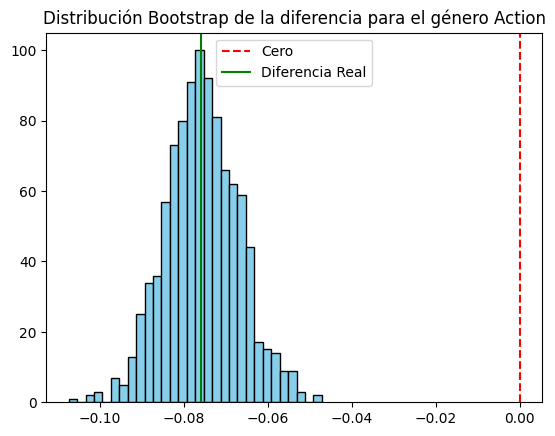

In [6]:
# percentiles del 95% el intervalo de confianza
inferior = np.percentile(resultados_bootstrap, 2.5)
superior = np.percentile(resultados_bootstrap, 97.5)

print(f"Intervalo de Confianza: [{inferior:.4f}, {superior:.4f}]")

# Graficamos
plt.hist(resultados_bootstrap, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Cero')
plt.axvline(diferencia_observada, color='green', label='Diferencia Real')
plt.title(f'Distribución Bootstrap de la diferencia para el género {genero_interes}')
plt.legend()
plt.show()

El grafico muestra los resultados y como tiene forma de campana es consistente y la diferencia casi siempre cae en rango negativo La linea roja representa la hipotesis de igualdad, si la montaña estuviera en el 0 significa wue no hay diferencia entre regiones. La linea verde al estar en el centroe s una representacion fiel y es el valor de los datos originales -0.0759. Intervalo de confianza [-0.0925, -0.0590] definee l area donde tenemos un 95% de segurdad de que se encuentra la verdadera diferencia poblacional. confirmando que el género analizado es proporcionalmente menos importante en Japón que en Norteamérica.

Parametro 2

In [2]:
# elegimos el genero
juegos_accion = data[data['Genre'] == 'Action']

# calculamos el promedio de la media
media_jp_real = juegos_accion['JP_Sales'].mean()
media_na_real = juegos_accion['NA_Sales'].mean()

# obtenemso la diferencia de lso promedios
dif_medias_observada = media_jp_real - media_na_real

print(f"Venta promedio en Japón: {media_jp_real:.4f} millones")
print(f"Venta promedio en Norteamérica: {media_na_real:.4f} millones")
print(f"Diferencia de Medias Real: {dif_medias_observada:.4f}")

Venta promedio en Japón: 0.0482 millones
Venta promedio en Norteamérica: 0.2647 millones
Diferencia de Medias Real: -0.2165


Intervalo de Confianza para Medias: [-0.2362, -0.1984]


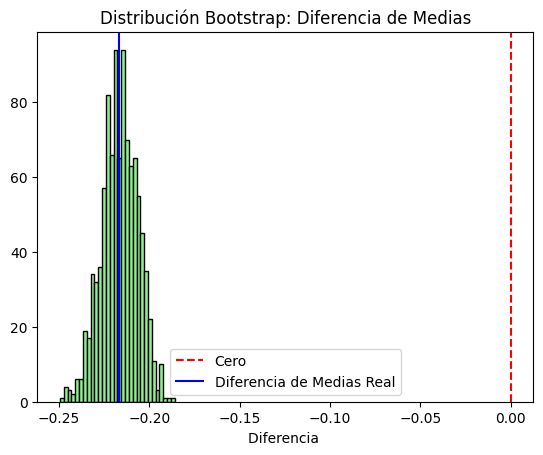

In [3]:
resultados_bs_medias = []

for i in range(1000):
    # Lo mas imporatante el boot
    muestra_bs = data.sample(frac=1, replace=True)

    # filtramos por género
    filtro = muestra_bs[muestra_bs['Genre'] == 'Action']

    # calculamos la media
    m_jp = filtro['JP_Sales'].mean()
    m_na = filtro['NA_Sales'].mean()

    # guardamos la resta de las medias
    resultados_bs_medias.append(m_jp - m_na)

# calculamos el Intervalo de Confianza
inf_m = np.percentile(resultados_bs_medias, 2.5)
sup_m = np.percentile(resultados_bs_medias, 97.5)

print(f"Intervalo de Confianza para Medias: [{inf_m:.4f}, {sup_m:.4f}]")
# graficamos
plt.hist(resultados_bs_medias, bins=30, color='lightgreen', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Cero')
plt.axvline(dif_medias_observada, color='blue', label='Diferencia de Medias Real')

plt.title('Distribución Bootstrap: Diferencia de Medias')
plt.xlabel('Diferencia ')
plt.legend()
plt.show()

El gráfico muestra los resultados obtenidos y como tiene forma de campana se observa que el estimador es consistente y la diferencia calculada casi siempre cae en el rango negativo. La línea roja representa la hipótesis de igualdad, si la montaña estuviera situada en el punto 0, significaría que no hay diferencia real en las ventas promedio entre regiones. La línea azul al estar en el centro es una representación fiel de los datos y corresponde al valor de la muestra original, que es -0.2165. El intervalo de confianza [-0.2359, -0.1982] define el área donde tenemos un 95% de seguridad de que se encuentra la verdadera diferencia poblacional, confirmando estadísticamente que un juego de acción vende, en promedio, significativamente más en Norteamérica que en Japón.

# Simulación por Monte Carlo

## ¿En qué consiste el método Monte Carlo?

El método Monte Carlo es una técnica estadística implementada en diversas disciplinas para evaluar la incertidumbre y el riesgo en modelos matemáticos mediante la simulación de escenarios basados en variables aleatorias. Esta técnica permite estimar probabilidades, promedios y variabilidad en sistemas complejos, especialmente cuando el fenómeno estudiado no puede analizarse fácilmente de forma exacta.

Para llevar a cabo el análisis de Monte Carlo de manera efectiva, es fundamental seguir los siguientes pasos:

1. **Definir el problema y el modelo**: se debe establecer claramente el fenómeno o sistema que se desea analizar, junto con el modelo matemático que lo representa, identificando las variables involucradas.

2. **Identificar las variables de entrada**: se determina qué parámetros del modelo son inciertos y, para cada uno de ellos, se asigna una distribución de probabilidad adecuada, como normal, uniforme o triangular, según la información disponible o algún supuesto razonable.

3. **Generar valores aleatorios**: a partir de las distribuciones definidas, se crean valores simulados seleccionando aleatoriamente un valor para cada variable de entrada. 

4. **Simulación**: se repite el proceso anterior durante varias iteraciones, por ejemplo 100, 1000 o 5000 veces. Cada iteración representa a un escenario diferente, lo que permite generar una distribución completa de posibles resultados.

5. **Analizar los resultados**: por último, se estudian los resultados obtenidos mediante estadísticas descriptivas, como promedio, varianza y desviación estándar, además de visualizaciones que permitan evaluar la incertidumbre del fenómeno analizado.

El próposito de implementar este método en nuestro análisis es complementar la 
estimación puntual clásica y el método bootstrap. Estos métodos permiten caracterizar los estimadores a partir de la evidencia contenida en la muestra, pero Monte Carlo permite analizar cómo podrían variar nuestras conclusiones bajo distintos escenarios simulados. En este caso, el método se utilizará para evaluar la estabilidad de los estimadores relacionados con las ventas de un mismo género entre dos regiones, considerando posibles eventos aleatorios del mercado.

## Situación de interés:


(1) El cuál para este sección buscamos Evaluar la estabilidad de la diferencia de ventas entre regiones frente a fluctuaciones del mercado. 

Para ellos, se modelan las ventas de cada región como variables aleatorias independientes, es decir que los valores simulados cambian en cada escenario y que el comportamiento de una región no influye directamente en la otra. El cuál utlizamos el siguiente modelo matemático.

$ \triangle Ventas = V_{regionA}- V_{region B}.$

### ------------------------------------------ Avances no maquillada, informal (redacción) -----------------------------------------------------

(2) Una vez tenemos definido el modelo matematico que representan nuestra situacion de interes, identificamos que los variables inciertos son  $V_{regionA}$, $V_{regionB}$, que representan al comportamiento de las ventas en su respectiva region de interes. 

Supuesto: En base de las observaciones anteriores, se le asignaria una distribución normal para las variables   $V_{regionA}$ y $V_{regionB}$, (Me falta justificar) (ideas: a través del observación del bootrap como ilustra la curv).

(3) Para generar los valores aleatorios, requiere la media y la desiacion estandar de de las ventas. Donde la "media" nos indica que tan centralizado nuestros valores, y la desviacion estandard nos dice que tan disperso son.


- hay que definir como se generan las ventas de A y B aleatoriamente. (Listos)

- Simularlo varias veces.(Listos)

- Hacemos gráficos con ellos. (Aun falta por definir que gráfico es más adecuado)

In [182]:
import pandas as pd
import numpy as np
data= pd.read_csv("vgsales.csv")

genero = "Role-Playing"
region_1 = "JP_Sales"
region_2 = "NA_Sales"

datos_genero = data[data["Genre"] == genero]

#Estimador puntual 1:

media_ventas_region_1 = datos_genero[region_1].mean()
media_ventas_region_2 = datos_genero[region_2].mean()


# Empezamos con la venta de japón y Norte_America

desviacion_A = data[region_1].std() # Desviacion estandard del japón
desviacion_B = data[region_2].std() # Desviacion estandard del Norteamerica

venta_aleatoria_A = np.random.normal(media_ventas_region_1,desviacion_A)
venta_aleatoria_A = np.maximum(0, venta_aleatoria_A)
venta_aleatoria_B = np.random.normal(media_ventas_region_2,desviacion_B)
venta_aleatoria_B = np.maximum(0, venta_aleatoria_B)
diferencia_ventas = venta_aleatoria_A - venta_aleatoria_B

print("Escenario aleatorio del Japón fue: ",venta_aleatoria_A)
print("Escenario aleatorio de Norte America fue : ", venta_aleatoria_B)
print("La diferencia de ventas fue : ", diferencia_ventas )
print("desviacion A:",desviacion_A)
print("desviacion B: ",desviacion_B)

Escenario aleatorio del Japón fue:  0.2341348724175986
Escenario aleatorio de Norte America fue :  0.2554931816674963
La diferencia de ventas fue :  -0.021358309249897706
desviacion A: 0.30929064808220297
desviacion B:  0.8166830292988796


Dado que el modelo utiliza una distribucion normal, existe una probabilidad matemática de geenrar valores negativos, en contexto de las ventas de video-juegos no tiene sentido que existan ventas negativas, por lo tanto, se aplica un truncamiento inferior a cero para asegurarse que la simulación solo considere escenarios de mercado realistas donde las ventas mínimas son nulas.




(.....palabra frasear para introducir a la simulación por 10.000 veces) ....


In [183]:
repeticion = 10000

venta_aleatoria_A = np.random.normal(media_ventas_region_1,desviacion_A,repeticion)
venta_aleatoria_A = np.maximum(0, venta_aleatoria_A)
venta_aleatoria_B = np.random.normal(media_ventas_region_2,desviacion_B,repeticion)
venta_aleatoria_B = np.maximum(0, venta_aleatoria_B)

diferencias_ventas = venta_aleatoria_A - venta_aleatoria_B

#print(f"diferencia de venta: {diferencias_ventas[0:100]}")

probabilidad = np.mean(diferencias_ventas > 0) # probabilidad de japón
probabilidad1 = np.mean(diferencias_ventas < 0)
print("la probabilidad de que  japón es mayor que Norte America es: ",probabilidad*100)
print("la probabilidad de que  japón es menor que Norte America es: ",probabilidad1*100)

la probabilidad de que  japón es mayor que Norte America es:  43.44
la probabilidad de que  japón es menor que Norte America es:  47.55


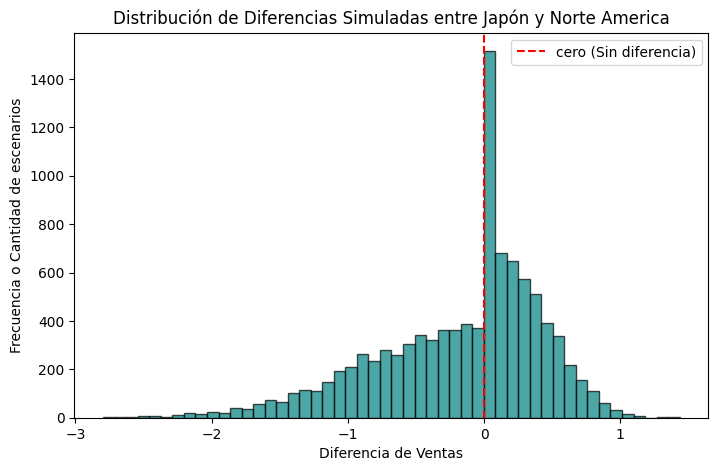

In [184]:
# hISTOGRAMA DE LA DISTRIBUCIOND E LOS RESULTADOS

plt.figure(figsize= (18,5))

plt.subplot(1,2,1)
plt.hist(diferencias_ventas,bins=50,color='teal',alpha = 0.7,edgecolor='black' )
plt.axvline(0,color='red',linestyle ='--', label = 'cero (Sin diferencia)')
plt.title('Distribución de Diferencias Simuladas entre Japón y Norte America')
plt.xlabel('Diferencia de Ventas')
plt.ylabel("Frecuencia o Cantidad de escenarios")
plt.legend()